# Species probability distribution analysis

Train one MLP on the full corpus (all datasets, L4 species labels),  
then extract softmax probabilities for every row and analyse  
the distribution of P(species) broken down by dataset.

No held-out split, no LODO — the goal is purely diagnostic:  
understand where the natural operating points are per species per dataset.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {DEVICE}  torch: {torch.__version__}')

device: cuda  torch: 2.5.1+cu121


In [2]:
# ── paths — adjust as needed ──────────────────────────────────────────────────
IN_DIR   = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN  = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR  = Path('./species_prob_analysis')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR  / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

BG_LABEL   = 'background'
LABEL_COL  = 'label_t4'      # adjust if your species column is named differently
DS_COL     = 'dataset'

print(f'meta : {META_PATH}  exists={META_PATH.exists()}')
print(f'X    : {X_PATH}     exists={X_PATH.exists()}')
print(f'out  : {OUT_DIR.resolve()}')

meta : /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X    : /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
out  : /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/species_prob_analysis


In [3]:
# ── load ──────────────────────────────────────────────────────────────────────
meta = pd.read_parquet(META_PATH)
X    = np.load(X_PATH, mmap_mode='r').astype(np.float32)

print(f'meta : {meta.shape}   X : {X.shape}')
print(f'datasets : {sorted(meta[DS_COL].unique())}')

def build_l4(row):
    t4 = row['label_t4']
    if pd.notna(t4): return t4
    t1 = row['label_t1']; t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'): return 'background'
    return None


meta_l4 = meta.copy(); meta_l4['label'] = meta_l4.apply(build_l4, axis=1)
meta_l4 = meta_l4.dropna(subset=['label']).copy()
print(f"\nL4: {len(meta_l4):,} rows"); print(meta_l4['label'].value_counts().to_string())
print()
print(pd.crosstab(meta_l4['dataset'], meta_l4['label']).to_string())


meta : (247630, 64)   X : (247630, 1536)
datasets : ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']

L4: 247,214 rows
label
background                    213606
Orcinus_orca                   21809
Tursiops_truncatus              7250
Delphinus_delphis               1292
Physeter_macrocephalus          1089
Globicephala_melas               721
Balaenoptera_physalus            539
Delphinidae_unknown              508
Grampus_griseus                  239
Stenella_coeruleoalba            144
Balaenoptera_acutorostrata        17

label               Balaenoptera_acutorostrata  Balaenoptera_physalus  Delphinidae_unknown  Delphinus_delphis  Globicephala_melas  Grampus_griseus  Orcinus_orca  Physeter_macrocephalus  Stenella_coeruleoalba  Tursiops_truncatus  background
dataset                                                                                             

In [4]:
# ── encode labels ─────────────────────────────────────────────────────────────
le          = LabelEncoder()
y_all       = le.fit_transform(meta_l4['label'].values).astype(np.int64)
X_np        = np.ascontiguousarray(X[meta_l4.index.values])  # 247214 rows, positional into X

class_names = list(le.classes_)
n_classes   = len(class_names)
bg_idx      = class_names.index(BG_LABEL) if BG_LABEL in class_names else -1
sp_indices  = [i for i in range(n_classes) if i != bg_idx]
sp_names    = [class_names[i] for i in sp_indices]

assert len(X_np) == len(y_all), f'mismatch: X_np={len(X_np)} y_all={len(y_all)}'

print(f'n_classes : {n_classes}   bg_idx : {bg_idx}')
print(f'species   : {sp_names}')
print(f'class dist :')
for i, cn in enumerate(class_names):
    print(f'  [{i:2d}] {cn:30s}  {(y_all==i).sum():>7,}')

n_classes : 11   bg_idx : 10
species   : ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']
class dist :
  [ 0] Balaenoptera_acutorostrata           17
  [ 1] Balaenoptera_physalus               539
  [ 2] Delphinidae_unknown                 508
  [ 3] Delphinus_delphis                 1,292
  [ 4] Globicephala_melas                  721
  [ 5] Grampus_griseus                     239
  [ 6] Orcinus_orca                     21,809
  [ 7] Physeter_macrocephalus            1,089
  [ 8] Stenella_coeruleoalba               144
  [ 9] Tursiops_truncatus                7,250
  [10] background                      213,606


In [5]:
# ── MLP (same architecture as LODO notebook) ──────────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def get_probs(model, X, batch_size=2048):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            logits = model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE))
            out.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.concatenate(out, axis=0)

In [6]:
from sklearn.preprocessing import StandardScaler

# ── scale ─────────────────────────────────────────────────────────────────────
sc   = StandardScaler().fit(X_np)
X_sc = sc.transform(X_np).astype(np.float32)

# ── train ─────────────────────────────────────────────────────────────────────
counts = np.bincount(y_all, minlength=n_classes).astype(np.float32)
w      = counts.sum() / (n_classes * np.clip(counts, 1, None))
crit   = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

model = MLP(X_sc.shape[1], n_classes).to(DEVICE)
opt   = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

dl = DataLoader(
    TensorDataset(torch.from_numpy(X_sc), torch.from_numpy(y_all)),
    batch_size=1024, shuffle=True, num_workers=0
)

EPOCHS = 30
for ep in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for xb, yb in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = crit(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item() * len(xb)
    if ep % 5 == 0 or ep == 1:
        print(f'ep {ep:3d}/{EPOCHS}  loss={total_loss/len(X_sc):.4f}')

print('training done')

ep   1/30  loss=0.4149
ep   5/30  loss=0.1188
ep  10/30  loss=0.1248
ep  15/30  loss=0.3231
ep  20/30  loss=0.3028
ep  25/30  loss=0.1844
ep  30/30  loss=0.1407
training done


In [7]:
# ── extract probabilities for the full corpus ─────────────────────────────────
probs = get_probs(model, X_np)   # (N, n_classes)
print(f'probs shape: {probs.shape}')

# quick sanity: train-set macro F1
preds = probs.argmax(axis=1)
f1    = f1_score(y_all, preds, average='macro', zero_division=0)
print(f'train macro F1 (sanity): {f1:.4f}')

probs shape: (247214, 11)
train macro F1 (sanity): 0.7379


In [9]:
# ── build long-form prob dataframe (species rows only) ────────────────────────
sp_mask = np.isin(y_all, sp_indices)   # only rows where true label is a species

rows = []
probs_sp  = probs[sp_mask]
y_sp      = y_all[sp_mask]
ds_sp     = meta_l4[DS_COL].values[sp_mask]

# for each species-true row, record P(each species class)
for sp_idx in sp_indices:
    sp_name  = class_names[sp_idx]
    # rows where this species is the TRUE label
    true_mask = (y_sp == sp_idx)
    if true_mask.sum() == 0:
        continue
    p_true    = probs_sp[true_mask, sp_idx]    # P(this species) when it IS true
    ds_labels = ds_sp[true_mask]
    for p, ds in zip(p_true, ds_labels):
        rows.append({'species': sp_name, 'dataset': ds, 'p_true': float(p)})

prob_df = pd.DataFrame(rows)
print(f'prob_df: {prob_df.shape}')
print(prob_df.groupby('species')['p_true'].describe().round(3).to_string())

prob_df: (33608, 3)
                              count   mean    std    min    25%    50%    75%    max
species                                                                             
Balaenoptera_acutorostrata     17.0  1.000  0.000  1.000  1.000  1.000  1.000  1.000
Balaenoptera_physalus         539.0  0.958  0.178  0.000  1.000  1.000  1.000  1.000
Delphinidae_unknown           508.0  0.840  0.231  0.023  0.806  0.953  0.985  1.000
Delphinus_delphis            1292.0  0.741  0.130  0.162  0.704  0.771  0.820  0.969
Globicephala_melas            721.0  0.616  0.231  0.051  0.429  0.623  0.820  0.989
Grampus_griseus               239.0  0.801  0.191  0.113  0.679  0.861  0.975  1.000
Orcinus_orca                21809.0  0.610  0.059  0.041  0.587  0.624  0.649  0.742
Physeter_macrocephalus       1089.0  0.848  0.207  0.137  0.740  0.964  0.992  1.000
Stenella_coeruleoalba         144.0  0.774  0.301  0.066  0.592  0.961  0.988  1.000
Tursiops_truncatus           7250.0  0.371  0

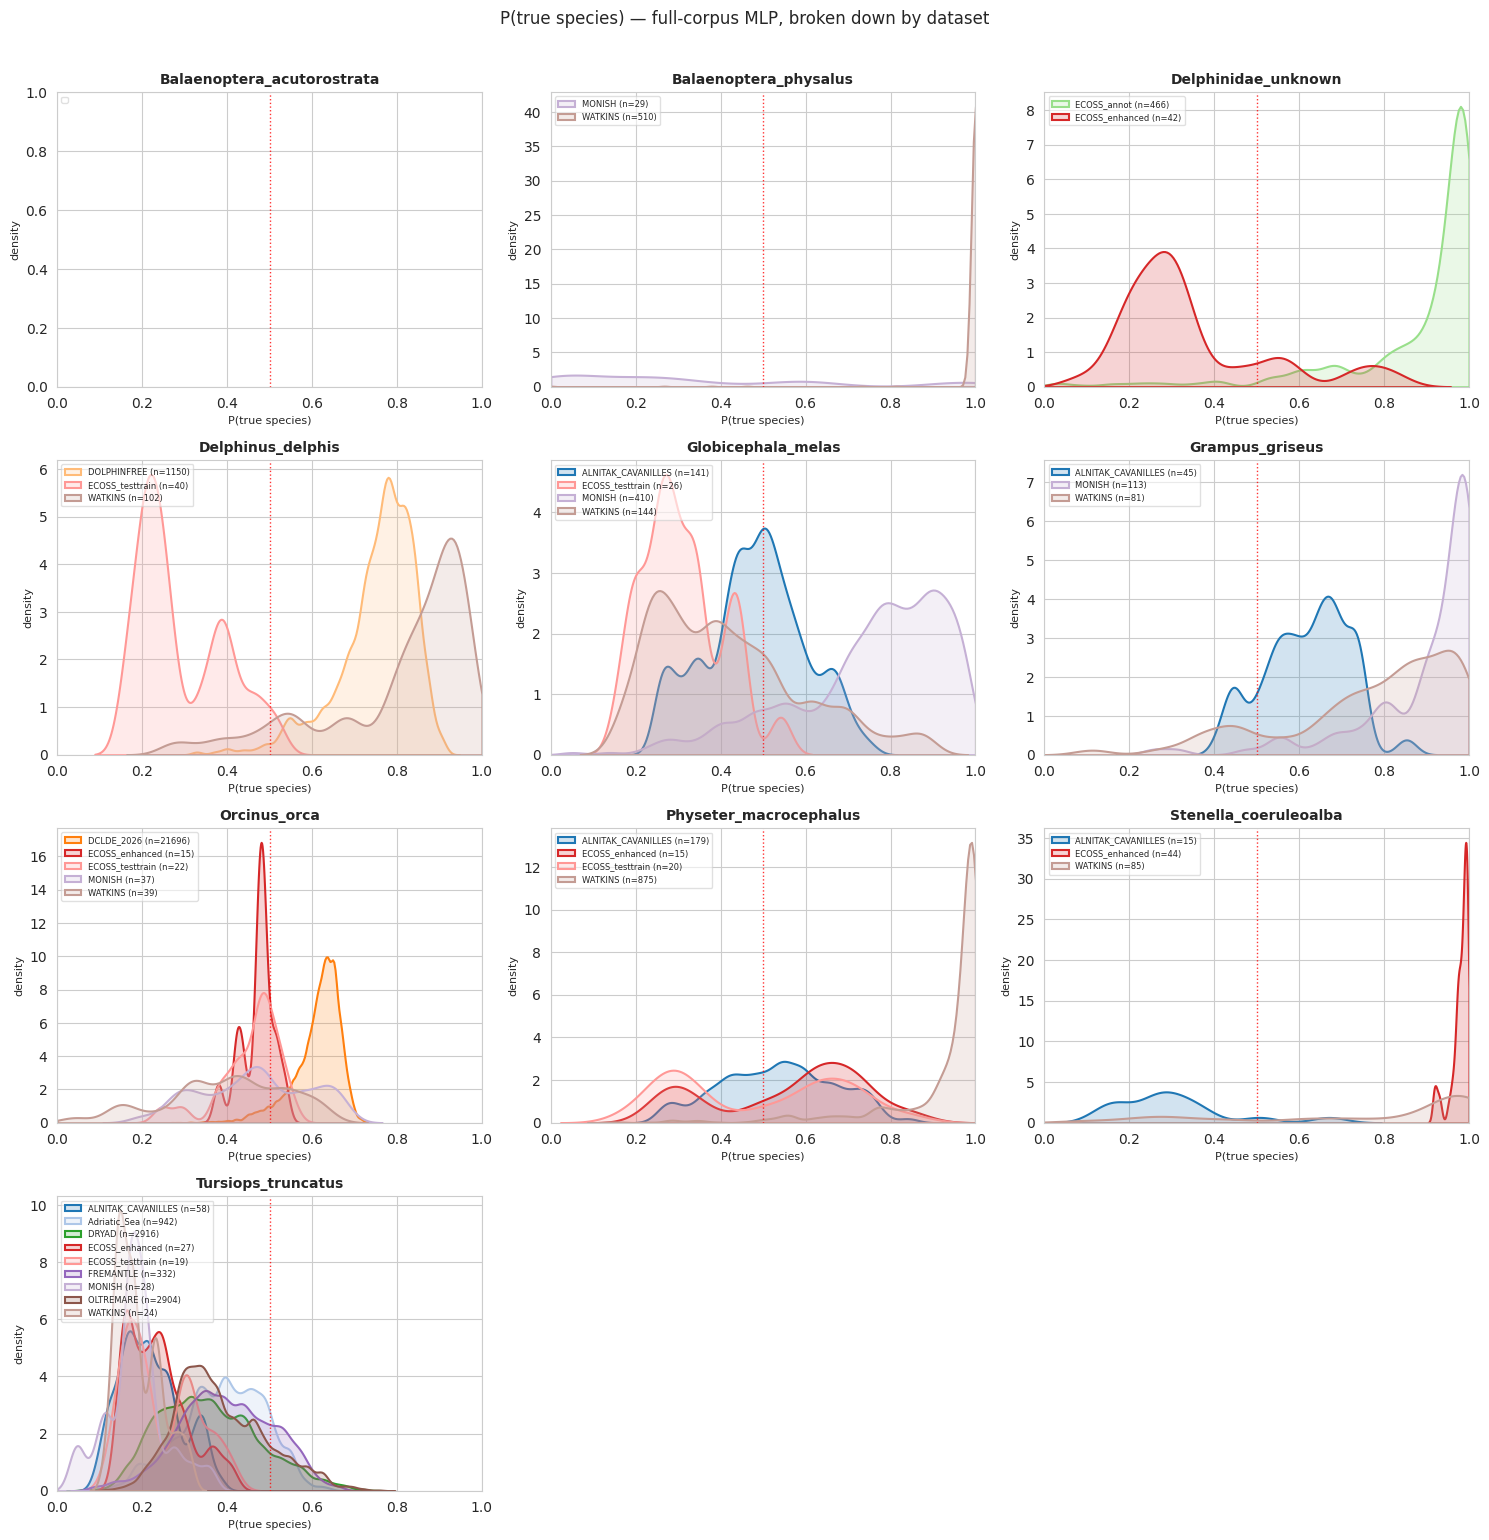

saved → species_prob_analysis/prob_dist_per_species_per_dataset.png


In [9]:
# ── plot 1: per-species KDE, coloured by dataset ──────────────────────────────
species_list = sorted(prob_df['species'].unique())
n_sp   = len(species_list)
ncols  = 3
nrows  = int(np.ceil(n_sp / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.8 * nrows))
axes = np.array(axes).flatten()

palette = sns.color_palette('tab20', n_colors=len(meta[DS_COL].unique()))
ds_color = {ds: palette[i] for i, ds in enumerate(sorted(meta[DS_COL].unique()))}

for i, sp in enumerate(species_list):
    ax  = axes[i]
    sub = prob_df[prob_df['species'] == sp]
    for ds, grp in sub.groupby('dataset'):
        vals = grp['p_true'].values
        if len(vals) < 10:
            ax.axvline(vals.mean(), linestyle='--', linewidth=1.2,
                       color=ds_color[ds], label=f'{ds} (n={len(vals)})')
        else:
            sns.kdeplot(vals, ax=ax, fill=True, alpha=0.20, color=ds_color[ds],
            linewidth=1.5, clip=(0, 1), bw_adjust=0.5,
            label=f'{ds} (n={len(vals)})')
    ax.axvline(0.5, color='red', linewidth=1.0, linestyle=':', alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_xlabel('P(true species)', fontsize=8)
    ax.set_ylabel('density', fontsize=8)
    ax.set_title(sp, fontsize=10, fontweight='bold')
    ax.legend(fontsize=6, loc='upper left', framealpha=0.6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('P(true species) — full-corpus MLP, broken down by dataset',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'prob_dist_per_species_per_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved → {OUT_DIR}/prob_dist_per_species_per_dataset.png')

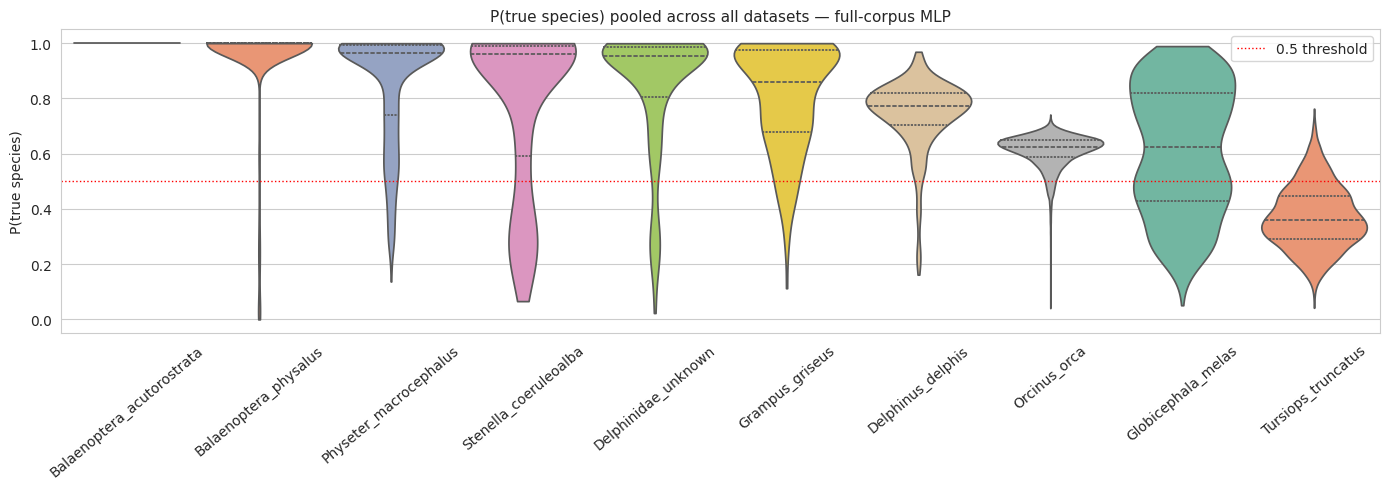

In [10]:
# ── plot 2: violin — all datasets pooled, one violin per species ──────────────
order = (prob_df.groupby('species')['p_true']
                .median()
                .sort_values(ascending=False)
                .index.tolist())

fig, ax = plt.subplots(figsize=(max(10, n_sp * 1.4), 5))
sns.violinplot(data=prob_df, x='species', y='p_true', order=order,
               inner='quartile', cut=0, palette='Set2', ax=ax)
ax.axhline(0.5, color='red', linewidth=1.0, linestyle=':', label='0.5 threshold')
ax.set_title('P(true species) pooled across all datasets — full-corpus MLP', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('P(true species)')
ax.tick_params(axis='x', rotation=40)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'prob_violin_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

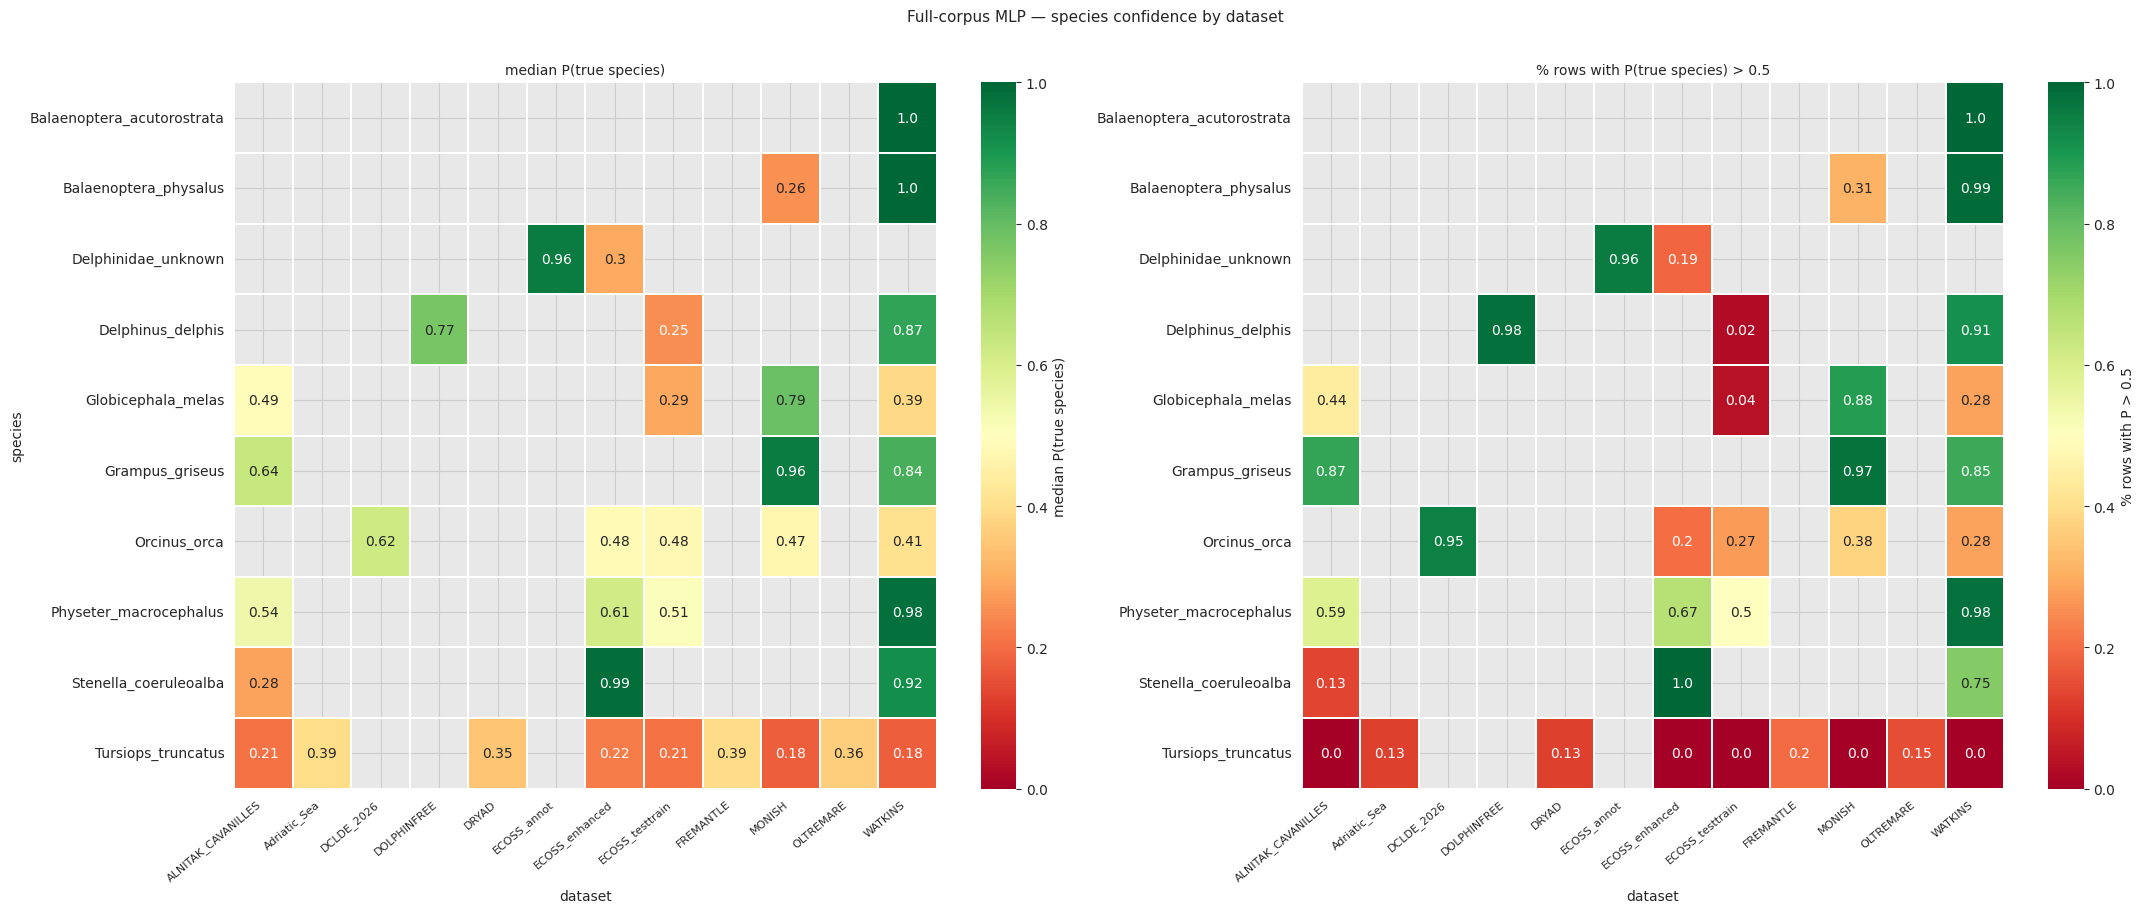

In [11]:
# ── plot 3: heatmap — median P(true species) per species × dataset ────────────
pivot_median = (
    prob_df.groupby(['species', 'dataset'])['p_true']
           .median()
           .unstack('dataset')
)
pivot_pct50 = (
    prob_df.groupby(['species', 'dataset'])['p_true']
           .apply(lambda x: (x > 0.5).mean())
           .unstack('dataset')
)

fig, axes = plt.subplots(1, 2, figsize=(max(16, len(pivot_median.columns) * 1.5 + 4), 
                                         max(5, len(pivot_median) * 0.7 + 2)))

annot_med = pivot_median.round(2).astype(str)
annot_med[pivot_median.isna()] = '—'
sns.heatmap(pivot_median, cmap='RdYlGn', vmin=0, vmax=1,
            annot=annot_med, fmt='', linewidths=0.3, ax=axes[0],
            mask=pivot_median.isna(),
            cbar_kws={'label': 'median P(true species)'})
axes[0].set_facecolor('#e8e8e8')
axes[0].set_title('median P(true species)', fontsize=10)
axes[0].set_xlabel('dataset'); axes[0].set_ylabel('species')
plt.setp(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8)

annot_pct = pivot_pct50.round(2).astype(str)
annot_pct[pivot_pct50.isna()] = '—'
sns.heatmap(pivot_pct50, cmap='RdYlGn', vmin=0, vmax=1,
            annot=annot_pct, fmt='', linewidths=0.3, ax=axes[1],
            mask=pivot_pct50.isna(),
            cbar_kws={'label': '% rows with P > 0.5'})
axes[1].set_facecolor('#e8e8e8')
axes[1].set_title('% rows with P(true species) > 0.5', fontsize=10)
axes[1].set_xlabel('dataset'); axes[1].set_ylabel('')
plt.setp(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=8)

plt.suptitle('Full-corpus MLP — species confidence by dataset', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'prob_heatmap_species_x_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── summary table ─────────────────────────────────────────────────────────────
summary = (
    prob_df
    .groupby(['species', 'dataset'])['p_true']
    .agg(
        n='count',
        p10=lambda x: np.percentile(x, 10),
        median='median',
        p90=lambda x: np.percentile(x, 90),
        pct_above_50=lambda x: (x > 0.5).mean(),
        pct_above_30=lambda x: (x > 0.3).mean(),
    )
    .reset_index()
    .sort_values(['species', 'median'], ascending=[True, False])
)

print(summary.to_string(index=False, float_format='{:.3f}'.format))
summary.to_csv(OUT_DIR / 'species_prob_summary.csv', index=False)
print(f'\nsaved → {OUT_DIR}/species_prob_summary.csv')

                   species            dataset     n   p10  median   p90  pct_above_50  pct_above_30
Balaenoptera_acutorostrata            WATKINS    17 1.000   1.000 1.000         1.000         1.000
     Balaenoptera_physalus            WATKINS   510 1.000   1.000 1.000         0.992         0.996
     Balaenoptera_physalus             MONISH    29 0.019   0.256 0.944         0.310         0.414
       Delphinidae_unknown        ECOSS_annot   466 0.658   0.960 0.994         0.957         0.974
       Delphinidae_unknown     ECOSS_enhanced    42 0.189   0.295 0.579         0.190         0.500
         Delphinus_delphis            WATKINS   102 0.523   0.868 0.956         0.912         0.980
         Delphinus_delphis        DOLPHINFREE  1150 0.626   0.771 0.846         0.981         1.000
         Delphinus_delphis    ECOSS_testtrain    40 0.190   0.251 0.439         0.025         0.375
        Globicephala_melas             MONISH   410 0.478   0.790 0.945         0.883         0.973
